# Lista 05 - Market Basket Analysis

Aplicacao do algoritmo Apriori para identificar associacoes entre produtos e
transformar os resultados em recomendacoes gerenciais.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)

SUPORTE_MINIMO = 0.05
CONFIANCA_MINIMA = 0.50
LIFT_RELEVANTE = 1.20
TAMANHO_MAXIMO_ITEMSET = 4

Matplotlib is building the font cache; this may take a moment.


## 1. Carregamento e validacao

Cada linha representa uma transacao. A coluna `transacao` e apenas um
identificador; as demais colunas indicam a presenca ou ausencia dos produtos.


In [2]:
df = pd.read_csv("basket_supermercado_1000.csv")
produtos = [coluna for coluna in df.columns if coluna != "transacao"]
cestas = df[produtos]

print(f"Transacoes: {len(df)}")
print(f"Produtos: {len(produtos)}")
print(f"Valores ausentes: {int(df.isna().sum().sum())}")
print(f"IDs duplicados: {int(df['transacao'].duplicated().sum())}")
print(f"Padroes de cesta distintos: {len(cestas.drop_duplicates())}")
print(f"Cestas vazias: {int((cestas.sum(axis=1) == 0).sum())}")
df.head()

Transacoes: 1000
Produtos: 20
Valores ausentes: 0
IDs duplicados: 0
Padroes de cesta distintos: 500
Cestas vazias: 16


,transacao,pao,leite,cafe,manteiga,acucar,arroz,feijao,macarrao,carne,...,peixe,ovos,queijo,presunto,cerveja,refrigerante,vinho,hortifruti,doces,limpeza
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,1,0
1,2,1,1,1,0,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3,1,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1,1,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
4,5,0,0,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,1,0,0


In [3]:
valores_validos = set(cestas.stack().unique()).issubset({0, 1})
if not valores_validos:
    raise ValueError("As colunas de produtos devem conter somente 0 e 1.")

if df["transacao"].duplicated().any():
    raise ValueError("A coluna transacao possui identificadores repetidos.")

Validacao concluida: colunas binarias e transacoes identificadas de forma unica.


Transacoes diferentes podem possuir a mesma composicao. Como os
identificadores sao unicos, os padroes repetidos foram preservados: eles
representam frequencia de compra, que e justamente a base do suporte.


## 2. Exploracao das compras


In [4]:
frequencia_produtos = (
    cestas.mean()
    .sort_values(ascending=False)
    .rename("suporte")
    .reset_index()
    .rename(columns={"index": "produto"})
)
frequencia_produtos["quantidade_transacoes"] = (
    frequencia_produtos["suporte"] * len(df)
).round().astype(int)

tamanho_cesta = cestas.sum(axis=1)
print(tamanho_cesta.describe().round(2))
frequencia_produtos

count    1000.00
mean        5.60
std         2.48
min         0.00
25%         4.00
50%         6.00
75%         7.00
max        12.00
dtype: float64


,produto,suporte,quantidade_transacoes
0,pao,0.633,633
1,leite,0.630,630
2,arroz,0.519,519
3,feijao,0.512,512
4,hortifruti,0.490,490
5,cafe,0.393,393
6,acucar,0.390,390
7,manteiga,0.346,346
8,cerveja,0.338,338
9,frango,0.288,288


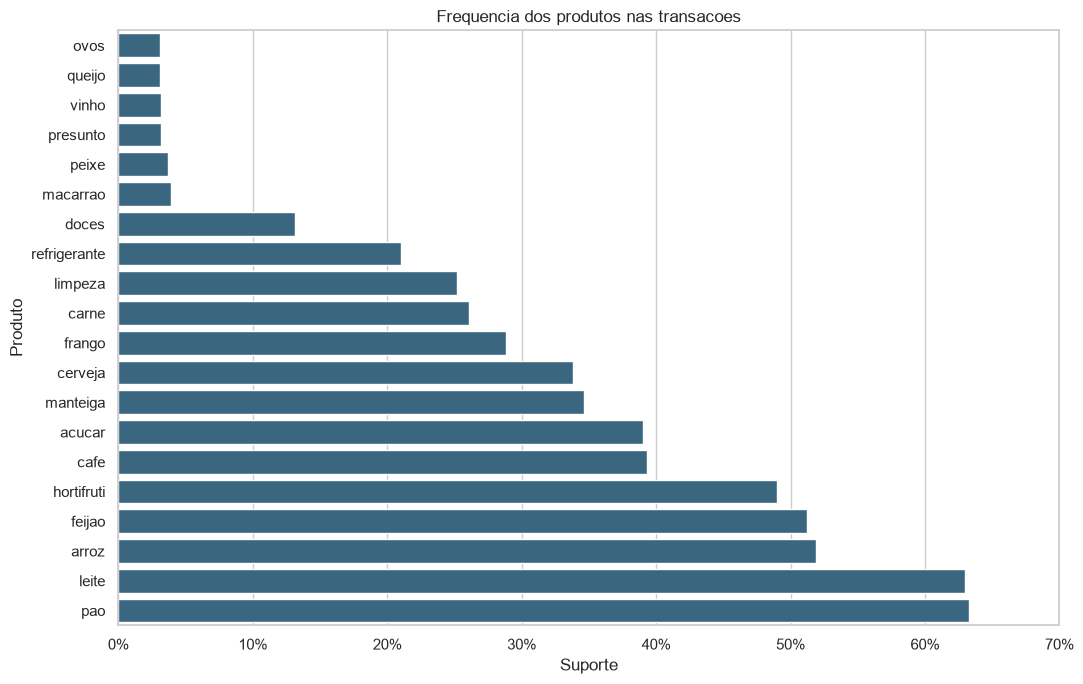

In [5]:
Path("graficos").mkdir(exist_ok=True)
Path("resultados").mkdir(exist_ok=True)

plt.figure(figsize=(11, 7))
grafico_frequencia = frequencia_produtos.sort_values("suporte")
sns.barplot(
    data=grafico_frequencia,
    x="suporte",
    y="produto",
    color="#2f6b8a"
)
plt.title("Frequencia dos produtos nas transacoes")
plt.xlabel("Suporte")
plt.ylabel("Produto")
plt.xlim(0, 0.70)
plt.gca().xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.savefig("graficos/frequencia_produtos.png", dpi=150)
plt.show()

## 3. Conjuntos frequentes com Apriori

O suporte minimo de 5% exige pelo menos 50 transacoes. O limite de quatro itens
mantem os conjuntos interpretaveis e reduz regras excessivamente especificas.


In [6]:
cestas_booleanas = cestas.astype(bool)

conjuntos_frequentes = apriori(
    cestas_booleanas,
    min_support=SUPORTE_MINIMO,
    use_colnames=True,
    max_len=TAMANHO_MAXIMO_ITEMSET
)
conjuntos_frequentes["tamanho"] = conjuntos_frequentes["itemsets"].map(len)
conjuntos_frequentes = conjuntos_frequentes.sort_values(
    ["support", "tamanho"],
    ascending=[False, True]
).reset_index(drop=True)

print(f"Conjuntos frequentes encontrados: {len(conjuntos_frequentes)}")
print(conjuntos_frequentes["tamanho"].value_counts().sort_index())
conjuntos_frequentes.head(20)

Conjuntos frequentes encontrados: 505
tamanho
1     14
2     84
3    198
4    209
Name: count, dtype: int64


,support,itemsets,tamanho
0,0.633,frozenset({pao}),1
1,0.630,frozenset({leite}),1
2,0.624,"frozenset({pao, leite})",2
3,0.519,frozenset({arroz}),1
4,0.512,frozenset({feijao}),1
5,0.503,"frozenset({arroz, feijao})",2
6,0.490,frozenset({hortifruti}),1
7,0.393,frozenset({cafe}),1
8,0.390,frozenset({acucar}),1
9,0.373,"frozenset({acucar, cafe})",2


## 4. Regras de associacao

- **Suporte:** parcela de transacoes que contem antecedente e consequente.
- **Confianca:** probabilidade do consequente quando o antecedente ocorre.
- **Lift:** intensidade da associacao em relacao ao acaso.
- **Leverage:** ganho absoluto de ocorrencia conjunta em relacao ao esperado.
- **Conviction:** intensidade da implicacao, considerando falhas da regra.


In [7]:
regras = association_rules(
    conjuntos_frequentes,
    metric="confidence",
    min_threshold=CONFIANCA_MINIMA
)

def formatar_itemset(itemset):
    return ", ".join(sorted(itemset))

regras["antecedente"] = regras["antecedents"].map(formatar_itemset)
regras["consequente"] = regras["consequents"].map(formatar_itemset)
regras["tamanho_antecedente"] = regras["antecedents"].map(len)
regras["tamanho_consequente"] = regras["consequents"].map(len)
regras = regras.sort_values(
    ["lift", "support", "confidence"],
    ascending=False
).reset_index(drop=True)

print(f"Regras geradas com confianca >= {CONFIANCA_MINIMA:.0%}: {len(regras)}")
regras[[
    "antecedente", "consequente", "support", "confidence",
    "lift", "leverage", "conviction"
]].head(20)

Regras geradas com confianca >= 50%: 1370


,antecedente,consequente,support,confidence,lift,leverage,conviction
0,"cafe, refrigerante","acucar, cerveja",0.071,0.865854,6.609570,0.060258,6.478000
1,"acucar, cerveja","cafe, refrigerante",0.071,0.541985,6.609570,0.060258,2.004300
2,"acucar, refrigerante","cafe, cerveja",0.071,0.855422,6.580167,0.060210,6.017500
3,"cafe, cerveja","acucar, refrigerante",0.071,0.546154,6.580167,0.060210,2.020508
4,"frango, refrigerante","cerveja, feijao",0.059,0.936508,5.641614,0.048542,13.135500
5,"frango, refrigerante","arroz, cerveja",0.059,0.936508,5.574452,0.048416,13.104000
6,"feijao, refrigerante","arroz, cerveja",0.097,0.923810,5.498866,0.079360,10.920000
7,"arroz, cerveja","feijao, refrigerante",0.097,0.577381,5.498866,0.079360,2.117746
8,"arroz, refrigerante","cerveja, feijao",0.097,0.906542,5.461097,0.079238,8.923800
9,"cerveja, feijao","arroz, refrigerante",0.097,0.584337,5.461097,0.079238,2.148377


In [8]:
regras_simples = regras[
    (regras["tamanho_antecedente"] == 1)
    & (regras["tamanho_consequente"] == 1)
].copy()

regras_relevantes = regras_simples[
    regras_simples["lift"] >= LIFT_RELEVANTE
].sort_values(
    ["lift", "support", "confidence"],
    ascending=False
).reset_index(drop=True)

print(f"Regras simples relevantes: {len(regras_relevantes)}")
regras_relevantes[[
    "antecedente", "consequente", "support", "confidence",
    "lift", "leverage", "conviction"
]]

Regras simples relevantes: 19


,antecedente,consequente,support,confidence,lift,leverage,conviction
0,refrigerante,cerveja,0.191,0.909524,2.690899,0.120020,7.316842
1,cerveja,refrigerante,0.191,0.565089,2.690899,0.120020,1.816463
2,doces,cerveja,0.115,0.877863,2.597227,0.070722,5.420125
3,acucar,cafe,0.373,0.956410,2.433614,0.219730,13.925294
4,cafe,acucar,0.373,0.949109,2.433614,0.219730,11.986500
5,feijao,arroz,0.503,0.982422,1.892913,0.237272,27.363556
6,arroz,feijao,0.503,0.969171,1.892913,0.237272,15.829500
7,carne,feijao,0.245,0.938697,1.833393,0.111368,7.960500
8,frango,feijao,0.270,0.937500,1.831055,0.122544,7.808000
9,feijao,frango,0.270,0.527344,1.831055,0.122544,1.506380


A direcao da regra importa. Por exemplo, `refrigerante -> cerveja`
possui confianca maior que `cerveja -> refrigerante`, embora as duas direcoes
tenham o mesmo suporte e lift. Isso acontece porque cerveja e mais frequente.


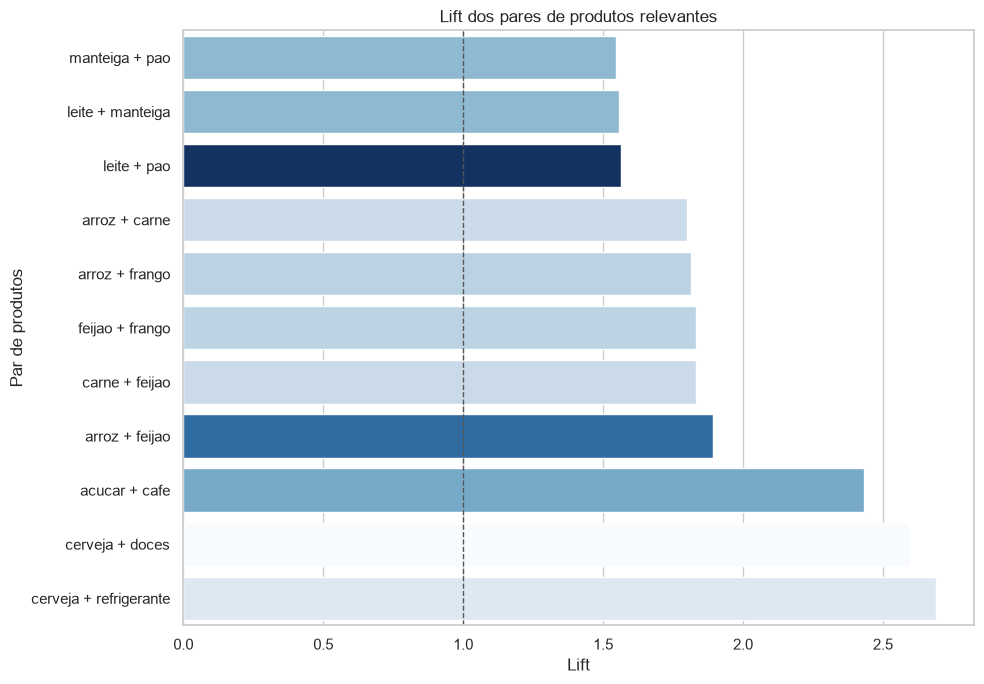

In [9]:
# Pares unicos para evitar barras duplicadas nas duas direcoes
pares_relevantes = regras_relevantes.copy()
pares_relevantes["par"] = pares_relevantes.apply(
    lambda linha: " + ".join(sorted([linha["antecedente"], linha["consequente"]])),
    axis=1
)
pares_relevantes = (
    pares_relevantes
    .sort_values(["lift", "support"], ascending=False)
    .drop_duplicates("par")
    .sort_values("lift")
)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=pares_relevantes,
    x="lift",
    y="par",
    hue="support",
    palette="Blues",
    legend=False
)
plt.axvline(1, color="#555555", linestyle="--", linewidth=1)
plt.title("Lift dos pares de produtos relevantes")
plt.xlabel("Lift")
plt.ylabel("Par de produtos")
plt.tight_layout()
plt.savefig("graficos/top_associacoes.png", dpi=150)
plt.show()

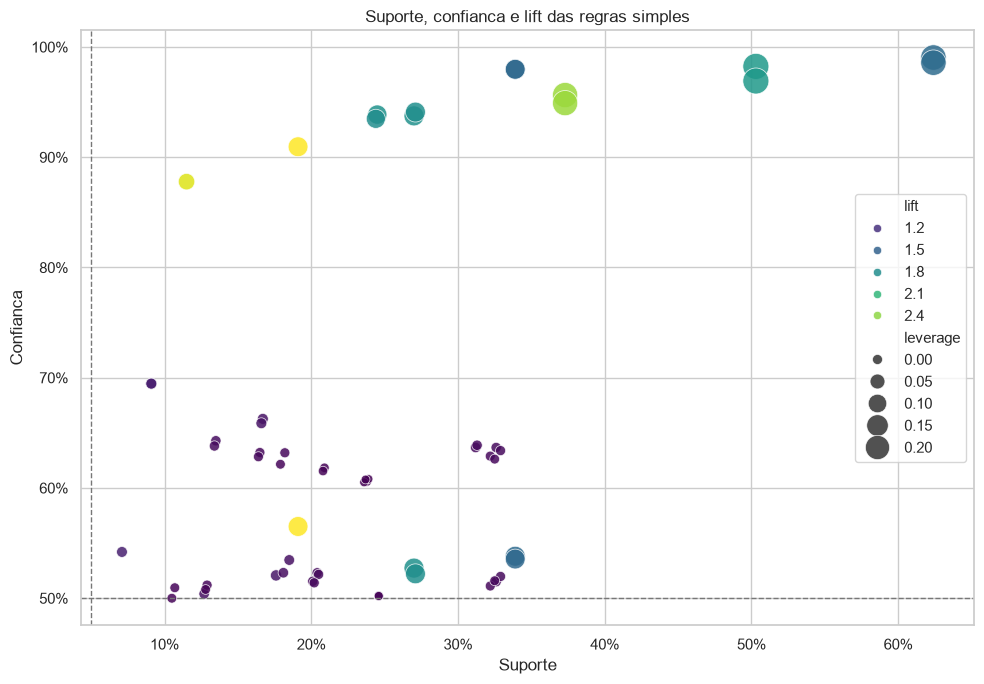

In [10]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=regras_simples,
    x="support",
    y="confidence",
    hue="lift",
    size="leverage",
    sizes=(40, 350),
    palette="viridis",
    alpha=0.85
)
plt.axhline(CONFIANCA_MINIMA, color="#777777", linestyle="--", linewidth=1)
plt.axvline(SUPORTE_MINIMO, color="#777777", linestyle="--", linewidth=1)
plt.title("Suporte, confianca e lift das regras simples")
plt.xlabel("Suporte")
plt.ylabel("Confianca")
plt.gca().xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.savefig("graficos/suporte_confianca_lift.png", dpi=150)
plt.show()

## 5. Produtos-ancora

O resumo abaixo considera como potenciais ancoras os produtos que aparecem no
antecedente de regras simples relevantes. Frequencia, quantidade de associacoes
e leverage devem ser avaliados em conjunto.


In [11]:
resumo_ancoras = (
    regras_relevantes
    .groupby("antecedente", as_index=False)
    .agg(
        suporte_produto=("antecedent support", "first"),
        associacoes_relevantes=("consequente", "nunique"),
        confianca_media=("confidence", "mean"),
        lift_maximo=("lift", "max"),
        leverage_total=("leverage", "sum")
    )
    .sort_values(
        ["associacoes_relevantes", "suporte_produto", "leverage_total"],
        ascending=False
    )
    .reset_index(drop=True)
    .rename(columns={"antecedente": "produto"})
)
resumo_ancoras

,produto,suporte_produto,associacoes_relevantes,confianca_media,lift_maximo,leverage_total
0,pao,0.633,2,0.760664,1.564733,0.345192
1,leite,0.630,2,0.764286,1.564733,0.346230
2,arroz,0.519,2,0.745665,1.892913,0.358800
3,feijao,0.512,2,0.754883,1.892913,0.359816
4,manteiga,0.346,2,0.979769,1.555189,0.241002
5,frango,0.288,2,0.939236,1.831055,0.244072
6,carne,0.261,2,0.936782,1.833393,0.219909
7,cafe,0.393,1,0.949109,2.433614,0.219730
8,acucar,0.390,1,0.956410,2.433614,0.219730
9,cerveja,0.338,1,0.565089,2.690899,0.120020


## 6. Regras potencialmente enganosas

Confianca alta nao garante associacao. Se o consequente ja for muito frequente,
a regra pode ter lift proximo de 1 e oferecer pouco ganho pratico.


In [12]:
regras_pouco_uteis = regras_simples[
    regras_simples["lift"].between(0.95, 1.05)
].sort_values("confidence", ascending=False)

regras_pouco_uteis[[
    "antecedente", "consequente", "support",
    "confidence", "lift", "leverage"
]].head(15)

,antecedente,consequente,support,confidence,lift,leverage
1067,limpeza,pao,0.167,0.662698,1.046917,0.007484
1069,limpeza,leite,0.166,0.658730,1.045603,0.007240
1145,refrigerante,pao,0.135,0.642857,1.015572,0.002070
1173,hortifruti,pao,0.313,0.638776,1.009124,0.002830
1156,refrigerante,leite,0.134,0.638095,1.012850,0.001700
1166,hortifruti,leite,0.312,0.636735,1.010690,0.003300
1187,feijao,pao,0.326,0.636719,1.005875,0.001904
1205,arroz,pao,0.329,0.633911,1.001440,0.000473
1219,carne,pao,0.165,0.632184,0.998711,-0.000213
1221,frango,pao,0.182,0.631944,0.998332,-0.000304


A regra `arroz -> pao`, por exemplo, tem confianca de aproximadamente
63%, mas lift proximo de 1. Pao ja esta presente em 63,3% de todas as cestas;
portanto, conhecer a compra de arroz praticamente nao melhora a previsao.

O caso oposto tambem exige cuidado: pares raros podem ter lift alto por
coincidencia. O suporte minimo de 5% impede que combinacoes com poucos registros
sejam usadas como recomendacao principal.


## 7. Exportacao dos resultados


In [13]:
conjuntos_exportacao = conjuntos_frequentes.copy()
conjuntos_exportacao["itemsets"] = conjuntos_exportacao["itemsets"].map(formatar_itemset)

colunas_regras = [
    "antecedente", "consequente", "antecedent support",
    "consequent support", "support", "confidence", "lift",
    "leverage", "conviction", "zhangs_metric"
]

conjuntos_exportacao.to_csv(
    "resultados/conjuntos_frequentes.csv",
    index=False
)
regras[colunas_regras].to_csv(
    "resultados/regras_associacao.csv",
    index=False
)
regras_relevantes[colunas_regras].to_csv(
    "resultados/regras_relevantes.csv",
    index=False
)
frequencia_produtos.to_csv(
    "resultados/frequencia_produtos.csv",
    index=False
)
resumo_ancoras.to_csv(
    "resultados/resumo_ancoras.csv",
    index=False
)

print("Resultados salvos nas pastas graficos/ e resultados/.")

Resultados salvos nas pastas graficos/ e resultados/.


## 8. Conclusoes e recomendacoes

- **Pao e leite** sao itens-ancora de alto alcance e se conectam a manteiga.
- **Arroz e feijao** formam a principal base de refeicao e se conectam a carne
  e frango.
- **Cafe e acucar** combinam alto suporte com lift elevado, sendo bons
  candidatos a promocao cruzada.
- **Cerveja e refrigerante** possuem o maior lift entre os pares com suporte
  relevante; doces tambem se associam a cerveja.
- Layouts, cupons e kits devem ser testados com controle de margem e estoque.
- Associacao nao prova causalidade. Os resultados devem apoiar, e nao substituir,
  testes comerciais e conhecimento do negocio.
